# =========================================================
# PHASE 11: FORECASTING & PREDICTIVE ANALYTICS
# Supply Chain Analytics Platform
# =========================================================

# Modules:
# 1. Import Libraries
# 2. Data Loading
# 3. Data Preparation
# 4. Monthly Time Series Creation
# 5. Trend Analysis
# 6. Moving Average Forecast
# 7. Exponential Smoothing Forecast
# 8. Linear Regression Forecast
# 9. ARIMA Forecast
# 10. Demand / Inventory Forecast
# 11. Profit Forecast
# 12. Order Volume Forecast
# 13. Final Forecast Summary
# =========================================================

In [4]:
# =========================================================
# MODULE 1: IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

In [6]:
# =========================================================
# MODULE 2: DATA LOADING
# =========================================================

file_path = r"C:\Projects\Supply Chain Analytics Platform\Supply Chain Analytics Platform File\SupplyChain_Cleaned.csv"

df = pd.read_csv(file_path)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Status,shipping date (DateOrders),Shipping Mode,Order Year,Order Month,Order Quarter,Shipping Delay,On Time Delivery,Profit Margin %,Delivery Performance
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,0,2018-02-03 22:56:00,Standard Class,2018,1,1,-1,Yes,27.841342,Early
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,0,2018-01-18 12:27:00,Standard Class,2018,1,1,1,No,-75.999999,Late
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,0,2018-01-17 12:06:00,Standard Class,2018,1,1,0,Yes,-75.600305,On Time
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,0,2018-01-16 11:45:00,Standard Class,2018,1,1,-1,Yes,6.974829,Early
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,0,2018-01-15 11:24:00,Standard Class,2018,1,1,-2,Yes,40.948896,Early


In [8]:
df.shape

(180519, 58)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 58 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [12]:
# =========================================================
# MODULE 3: DATA PREPARATION
# =========================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_")
)

df.columns.tolist()

['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'benefit_per_order',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_email',
 'customer_fname',
 'customer_id',
 'customer_lname',
 'customer_password',
 'customer_segment',
 'customer_state',
 'customer_street',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date_dateorders',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_image',
 'product_name',
 'product_price',
 'product_status',
 'shipping_date_dateor

In [14]:
# Rename important columns if needed

rename_map = {
    "order_date_dateorders": "order_date",
    "shipping_date_dateorders": "shipping_date",
    "sales": "sales",
    "order_profit_per_order": "profit",
    "order_item_quantity": "quantity",
    "shipping_delay": "shipping_delay",
    "delivery_performance": "delivery_performance",
    "category_name": "category_name",
    "customer_segment": "customer_segment"
}

df = df.rename(columns=rename_map)

df.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,product_status,shipping_date,shipping_mode,order_year,order_month,order_quarter,shipping_delay,on_time_delivery,profit_margin_%,delivery_performance
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,0,2018-02-03 22:56:00,Standard Class,2018,1,1,-1,Yes,27.841342,Early
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,0,2018-01-18 12:27:00,Standard Class,2018,1,1,1,No,-75.999999,Late
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,0,2018-01-17 12:06:00,Standard Class,2018,1,1,0,Yes,-75.600305,On Time
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,0,2018-01-16 11:45:00,Standard Class,2018,1,1,-1,Yes,6.974829,Early
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,0,2018-01-15 11:24:00,Standard Class,2018,1,1,-2,Yes,40.948896,Early


In [16]:
# Convert date column

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df = df.dropna(subset=["order_date"])

df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["month_start"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

df[["order_date", "month_start", "sales", "profit", "quantity"]].head()

,order_date,month_start,sales,profit,quantity
0,2018-01-31 22:56:00,2018-01-01,327.75,91.250000,1
1,2018-01-13 12:27:00,2018-01-01,327.75,-249.089996,1
2,2018-01-13 12:06:00,2018-01-01,327.75,-247.779999,1
3,2018-01-13 11:45:00,2018-01-01,327.75,22.860001,1
4,2018-01-13 11:24:00,2018-01-01,327.75,134.210007,1


In [18]:
# Check main columns

main_cols = ["sales", "profit", "quantity", "shipping_delay"]

df[main_cols].describe()

,sales,profit,quantity,shipping_delay
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,203.772096,21.974989,2.127638,0.565807
std,132.273077,104.433526,1.453451,1.490966
min,9.990000,-4274.979980,1.000000,-2.000000
25%,119.980003,7.000000,1.000000,0.000000
50%,199.919998,31.520000,1.000000,1.000000
75%,299.950012,64.800003,3.000000,1.000000
max,1999.989990,911.799988,5.000000,4.000000


In [20]:
# =========================================================
# MODULE 4: MONTHLY TIME SERIES CREATION
# =========================================================

monthly_data = df.groupby("month_start").agg(
    monthly_sales=("sales", "sum"),
    monthly_profit=("profit", "sum"),
    monthly_quantity=("quantity", "sum"),
    monthly_orders=("order_id", "nunique"),
    avg_shipping_delay=("shipping_delay", "mean")
).reset_index()

monthly_data = monthly_data.sort_values("month_start")

monthly_data.head()

,month_start,monthly_sales,monthly_profit,monthly_quantity,monthly_orders,avg_shipping_delay
0,2015-01-01,1.051590e+06,111660.740132,11854,1787,0.540210
1,2015-02-01,9.270099e+05,99140.660196,10438,1585,0.598435
2,2015-03-01,1.051254e+06,113778.210191,12062,1781,0.571988
3,2015-04-01,1.014463e+06,108083.679957,11287,1710,0.547405
4,2015-05-01,1.050478e+06,112147.900143,11902,1776,0.556655


In [22]:
monthly_data.tail()

,month_start,monthly_sales,monthly_profit,monthly_quantity,monthly_orders,avg_shipping_delay
32,2017-09-01,1.143775e+06,122462.390153,10502,1723,0.532087
33,2017-10-01,1.073994e+06,113447.169883,2490,2101,0.536585
34,2017-11-01,6.269144e+05,67791.250205,2055,2055,0.579562
35,2017-12-01,5.039108e+05,65837.629745,2124,2124,0.577213
36,2018-01-01,3.316501e+05,33841.889977,2123,2123,0.612812


In [24]:
monthly_data.shape

(37, 6)

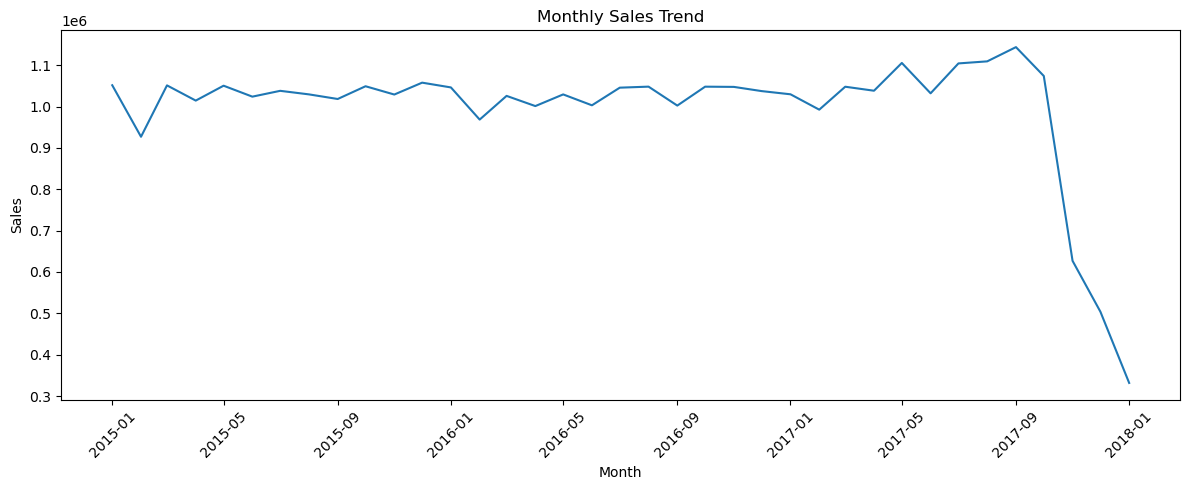

In [26]:
# =========================================================
# MODULE 5: TREND ANALYSIS
# =========================================================

plt.figure(figsize=(12,5))
plt.plot(monthly_data["month_start"], monthly_data["monthly_sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

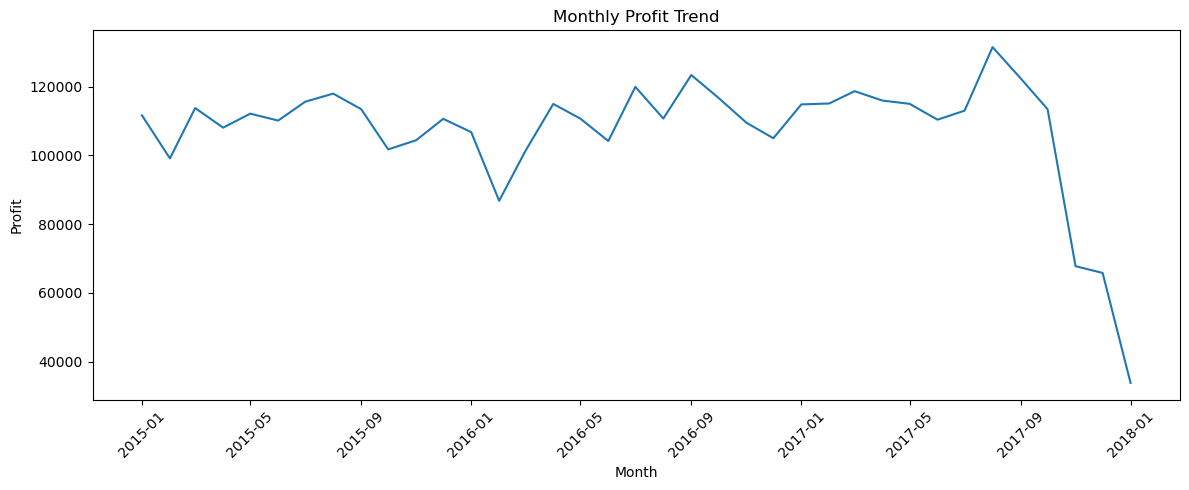

In [28]:
plt.figure(figsize=(12,5))
plt.plot(monthly_data["month_start"], monthly_data["monthly_profit"])
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# =========================================================
# MODULE 6: MOVING AVERAGE FORECAST
# =========================================================

monthly_data["sales_3_month_ma"] = monthly_data["monthly_sales"].rolling(window=3).mean()
monthly_data["sales_6_month_ma"] = monthly_data["monthly_sales"].rolling(window=6).mean()

monthly_data[["month_start", "monthly_sales", "sales_3_month_ma", "sales_6_month_ma"]].tail()

,month_start,monthly_sales,sales_3_month_ma,sales_6_month_ma
32,2017-09-01,1.143775e+06,1.119162e+06,1.088897e+06
33,2017-10-01,1.073994e+06,1.109035e+06,1.094842e+06
34,2017-11-01,6.269144e+05,9.482279e+05,1.015080e+06
35,2017-12-01,5.039108e+05,7.349398e+05,9.270508e+05
36,2018-01-01,3.316501e+05,4.874918e+05,7.982636e+05


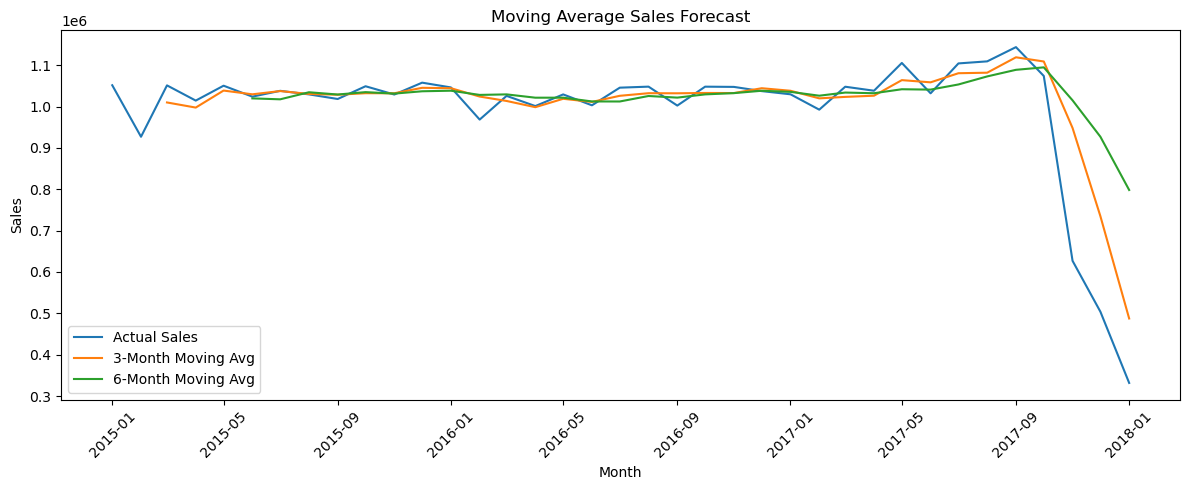

In [32]:
plt.figure(figsize=(12,5))
plt.plot(monthly_data["month_start"], monthly_data["monthly_sales"], label="Actual Sales")
plt.plot(monthly_data["month_start"], monthly_data["sales_3_month_ma"], label="3-Month Moving Avg")
plt.plot(monthly_data["month_start"], monthly_data["sales_6_month_ma"], label="6-Month Moving Avg")
plt.title("Moving Average Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Future forecast using last 3-month moving average

future_months = 6

last_date = monthly_data["month_start"].max()
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=future_months,
    freq="MS"
)

moving_avg_forecast_value = monthly_data["monthly_sales"].tail(3).mean()

moving_avg_forecast = pd.DataFrame({
    "forecast_month": future_dates,
    "moving_average_sales_forecast": moving_avg_forecast_value
})

moving_avg_forecast

,forecast_month,moving_average_sales_forecast
0,2018-02-01,487491.772056
1,2018-03-01,487491.772056
2,2018-04-01,487491.772056
3,2018-05-01,487491.772056
4,2018-06-01,487491.772056
5,2018-07-01,487491.772056


In [36]:
# =========================================================
# MODULE 7: EXPONENTIAL SMOOTHING FORECAST
# =========================================================

sales_series = monthly_data.set_index("month_start")["monthly_sales"]

ets_model = ExponentialSmoothing(
    sales_series,
    trend="add",
    seasonal=None
)

ets_fit = ets_model.fit()

ets_forecast = ets_fit.forecast(future_months)

ets_forecast_df = pd.DataFrame({
    "forecast_month": ets_forecast.index,
    "ets_sales_forecast": ets_forecast.values
})

ets_forecast_df

,forecast_month,ets_sales_forecast
0,2018-02-01,160545.335552
1,2018-03-01,-11541.192242
2,2018-04-01,-183627.720035
3,2018-05-01,-355714.247829
4,2018-06-01,-527800.775623
5,2018-07-01,-699887.303416


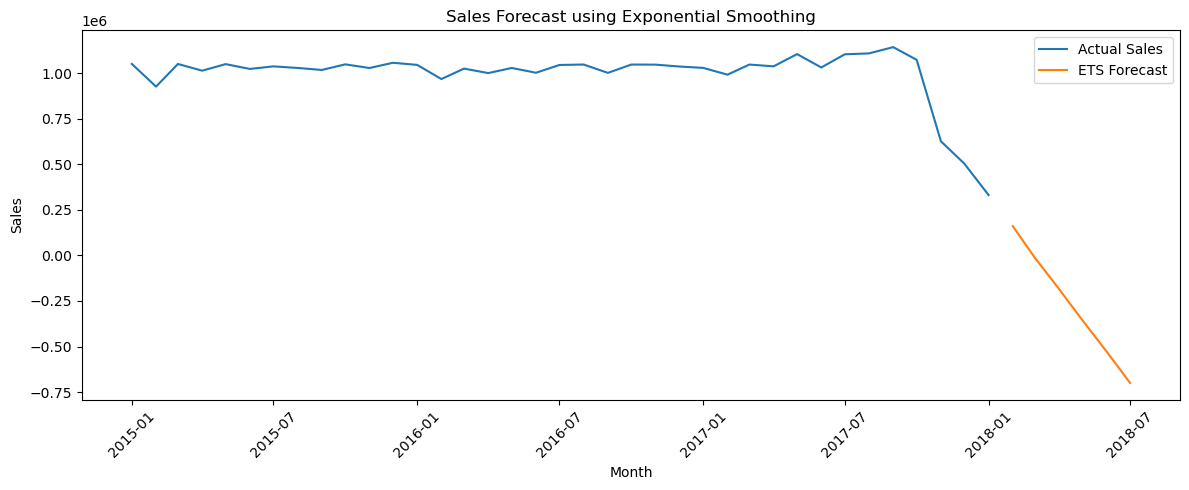

In [38]:
plt.figure(figsize=(12,5))
plt.plot(sales_series.index, sales_series.values, label="Actual Sales")
plt.plot(ets_forecast.index, ets_forecast.values, label="ETS Forecast")
plt.title("Sales Forecast using Exponential Smoothing")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
# =========================================================
# MODULE 8: LINEAR REGRESSION FORECAST
# =========================================================

monthly_data["month_index"] = np.arange(len(monthly_data))

X = monthly_data[["month_index"]]
y = monthly_data["monthly_sales"]

lr_model = LinearRegression()
lr_model.fit(X, y)

future_index = np.arange(len(monthly_data), len(monthly_data) + future_months).reshape(-1, 1)

lr_forecast_values = lr_model.predict(future_index)

lr_forecast_df = pd.DataFrame({
    "forecast_month": future_dates,
    "linear_regression_sales_forecast": lr_forecast_values
})

lr_forecast_df

,forecast_month,linear_regression_sales_forecast
0,2018-02-01,895636.150436
1,2018-03-01,890449.525333
2,2018-04-01,885262.900230
3,2018-05-01,880076.275127
4,2018-06-01,874889.650024
5,2018-07-01,869703.024922


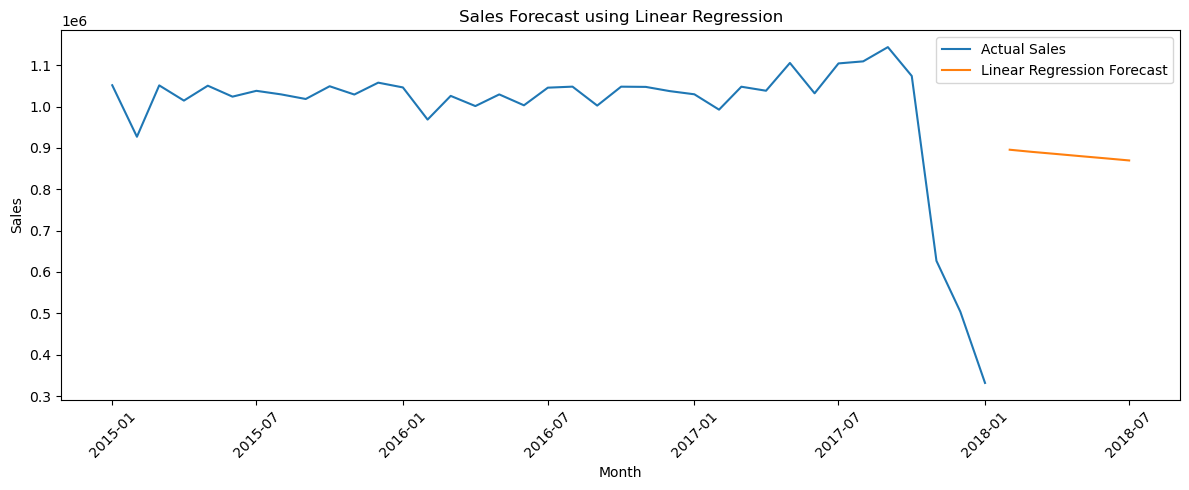

In [42]:
plt.figure(figsize=(12,5))
plt.plot(monthly_data["month_start"], monthly_data["monthly_sales"], label="Actual Sales")
plt.plot(future_dates, lr_forecast_values, label="Linear Regression Forecast")
plt.title("Sales Forecast using Linear Regression")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# =========================================================
# MODULE 9: ARIMA FORECAST
# =========================================================

arima_model = ARIMA(sales_series, order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=future_months)

arima_forecast_df = pd.DataFrame({
    "forecast_month": future_dates,
    "arima_sales_forecast": arima_forecast.values
})

arima_forecast_df

,forecast_month,arima_sales_forecast
0,2018-02-01,322219.157766
1,2018-03-01,315053.434054
2,2018-04-01,309608.854657
3,2018-05-01,305472.015726
4,2018-06-01,302328.809412
5,2018-07-01,299940.573829


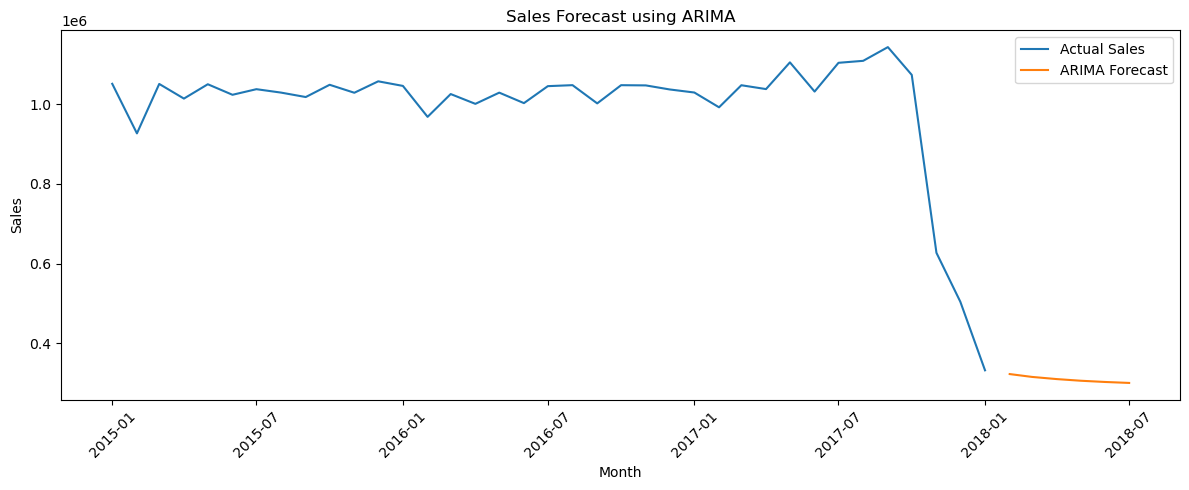

In [46]:
plt.figure(figsize=(12,5))
plt.plot(sales_series.index, sales_series.values, label="Actual Sales")
plt.plot(future_dates, arima_forecast.values, label="ARIMA Forecast")
plt.title("Sales Forecast using ARIMA")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
# =========================================================
# MODULE 10: DEMAND / INVENTORY FORECAST
# =========================================================

quantity_series = monthly_data.set_index("month_start")["monthly_quantity"]

quantity_model = ExponentialSmoothing(
    quantity_series,
    trend="add",
    seasonal=None
)

quantity_fit = quantity_model.fit()

quantity_forecast = quantity_fit.forecast(future_months)

quantity_forecast_df = pd.DataFrame({
    "forecast_month": future_dates,
    "demand_forecast_quantity": quantity_forecast.values
})

quantity_forecast_df

,forecast_month,demand_forecast_quantity
0,2018-02-01,1660.107239
1,2018-03-01,1222.520121
2,2018-04-01,784.933003
3,2018-05-01,347.345886
4,2018-06-01,-90.241232
5,2018-07-01,-527.828349


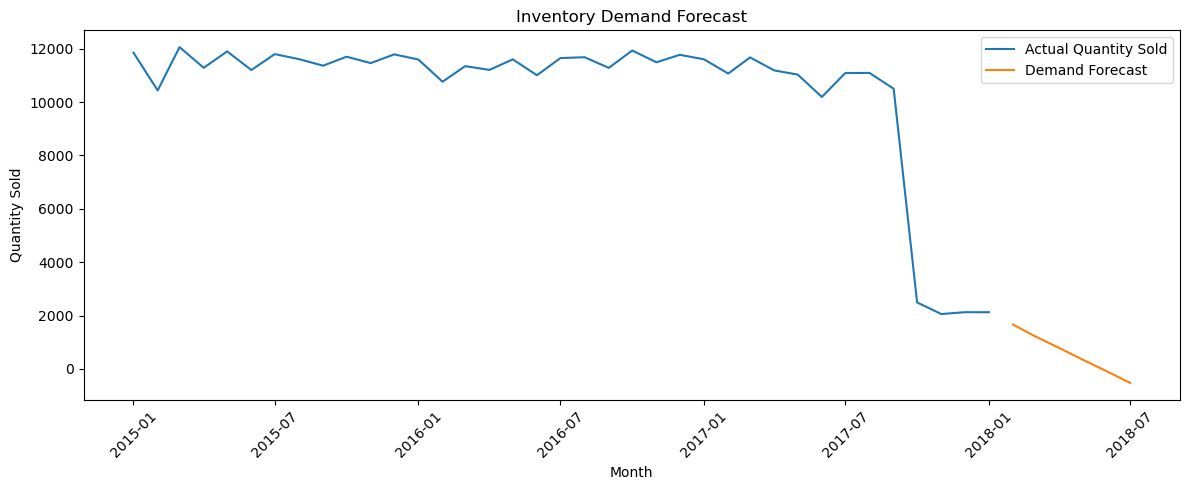

In [50]:
plt.figure(figsize=(12,5))
plt.plot(quantity_series.index, quantity_series.values, label="Actual Quantity Sold")
plt.plot(future_dates, quantity_forecast.values, label="Demand Forecast")
plt.title("Inventory Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
# =========================================================
# MODULE 11: PROFIT FORECAST
# =========================================================

profit_series = monthly_data.set_index("month_start")["monthly_profit"]

profit_model = ExponentialSmoothing(
    profit_series,
    trend="add",
    seasonal=None
)

profit_fit = profit_model.fit()

profit_forecast = profit_fit.forecast(future_months)

profit_forecast_df = pd.DataFrame({
    "forecast_month": future_dates,
    "profit_forecast": profit_forecast.values
})

profit_forecast_df

,forecast_month,profit_forecast
0,2018-02-01,23422.375206
1,2018-03-01,9241.267021
2,2018-04-01,-4939.841164
3,2018-05-01,-19120.949349
4,2018-06-01,-33302.057534
5,2018-07-01,-47483.165719


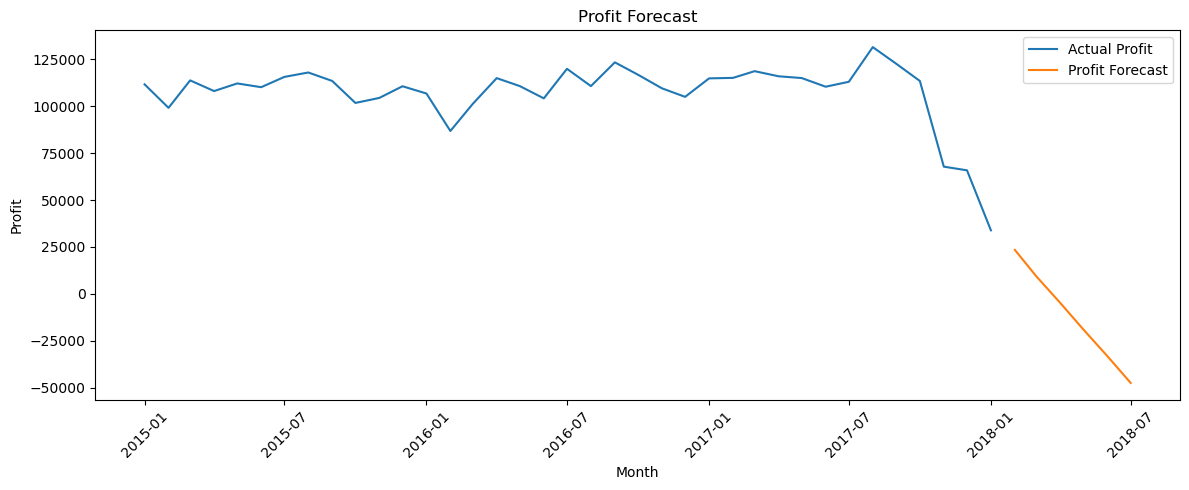

In [54]:
plt.figure(figsize=(12,5))
plt.plot(profit_series.index, profit_series.values, label="Actual Profit")
plt.plot(future_dates, profit_forecast.values, label="Profit Forecast")
plt.title("Profit Forecast")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
# =========================================================
# MODULE 12: ORDER VOLUME FORECAST
# =========================================================

orders_series = monthly_data.set_index("month_start")["monthly_orders"]

orders_model = ExponentialSmoothing(
    orders_series,
    trend="add",
    seasonal=None
)

orders_fit = orders_model.fit()

orders_forecast = orders_fit.forecast(future_months)

orders_forecast_df = pd.DataFrame({
    "forecast_month": future_dates,
    "order_volume_forecast": orders_forecast.values
})

orders_forecast_df

,forecast_month,order_volume_forecast
0,2018-02-01,2224.526581
1,2018-03-01,2300.652915
2,2018-04-01,2376.779249
3,2018-05-01,2452.905583
4,2018-06-01,2529.031916
5,2018-07-01,2605.158250


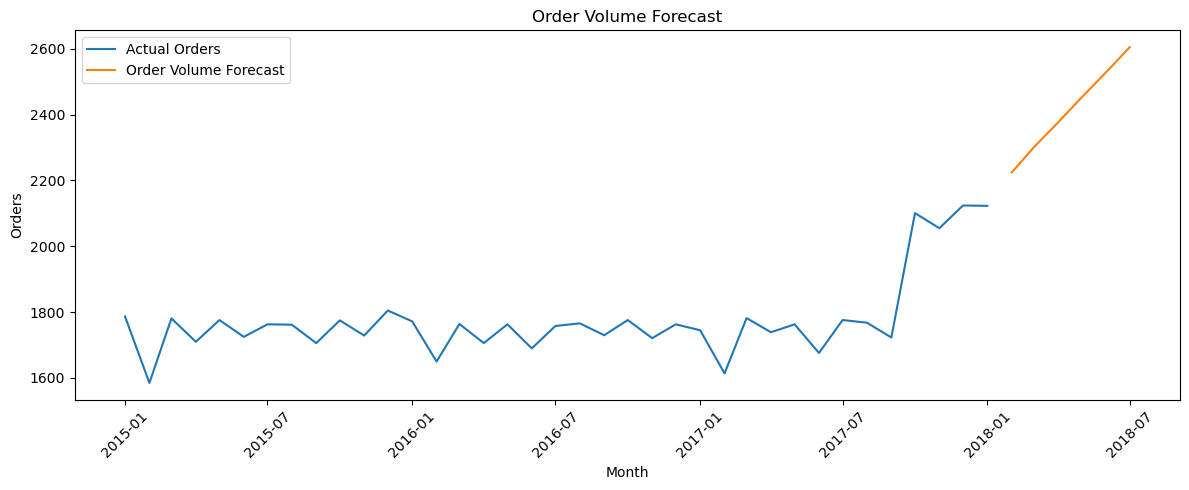

In [58]:
plt.figure(figsize=(12,5))
plt.plot(orders_series.index, orders_series.values, label="Actual Orders")
plt.plot(future_dates, orders_forecast.values, label="Order Volume Forecast")
plt.title("Order Volume Forecast")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# =========================================================
# MODULE 13: FINAL FORECAST SUMMARY
# =========================================================

forecast_summary = pd.DataFrame({
    "forecast_month": future_dates,
    "moving_average_sales_forecast": moving_avg_forecast["moving_average_sales_forecast"].values,
    "ets_sales_forecast": ets_forecast.values,
    "linear_regression_sales_forecast": lr_forecast_values,
    "arima_sales_forecast": arima_forecast.values,
    "demand_forecast_quantity": quantity_forecast.values,
    "profit_forecast": profit_forecast.values,
    "order_volume_forecast": orders_forecast.values
})

forecast_summary

,forecast_month,moving_average_sales_forecast,ets_sales_forecast,linear_regression_sales_forecast,arima_sales_forecast,demand_forecast_quantity,profit_forecast,order_volume_forecast
0,2018-02-01,487491.772056,160545.335552,895636.150436,322219.157766,1660.107239,23422.375206,2224.526581
1,2018-03-01,487491.772056,-11541.192242,890449.525333,315053.434054,1222.520121,9241.267021,2300.652915
2,2018-04-01,487491.772056,-183627.720035,885262.900230,309608.854657,784.933003,-4939.841164,2376.779249
3,2018-05-01,487491.772056,-355714.247829,880076.275127,305472.015726,347.345886,-19120.949349,2452.905583
4,2018-06-01,487491.772056,-527800.775623,874889.650024,302328.809412,-90.241232,-33302.057534,2529.031916
5,2018-07-01,487491.772056,-699887.303416,869703.024922,299940.573829,-527.828349,-47483.165719,2605.158250


In [62]:
# Round forecast values

forecast_summary_rounded = forecast_summary.copy()

for col in forecast_summary_rounded.columns:
    if col != "forecast_month":
        forecast_summary_rounded[col] = forecast_summary_rounded[col].round(2)

forecast_summary_rounded

,forecast_month,moving_average_sales_forecast,ets_sales_forecast,linear_regression_sales_forecast,arima_sales_forecast,demand_forecast_quantity,profit_forecast,order_volume_forecast
0,2018-02-01,487491.77,160545.34,895636.15,322219.16,1660.11,23422.38,2224.53
1,2018-03-01,487491.77,-11541.19,890449.53,315053.43,1222.52,9241.27,2300.65
2,2018-04-01,487491.77,-183627.72,885262.90,309608.85,784.93,-4939.84,2376.78
3,2018-05-01,487491.77,-355714.25,880076.28,305472.02,347.35,-19120.95,2452.91
4,2018-06-01,487491.77,-527800.78,874889.65,302328.81,-90.24,-33302.06,2529.03
5,2018-07-01,487491.77,-699887.30,869703.02,299940.57,-527.83,-47483.17,2605.16


In [64]:
# =========================================================
# MODULE 14: MODEL EVALUATION
# =========================================================

# Train-test split for sales forecasting

train_size = int(len(sales_series) * 0.8)

train = sales_series.iloc[:train_size]
test = sales_series.iloc[train_size:]

ets_eval_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

ets_eval_fit = ets_eval_model.fit()
ets_predictions = ets_eval_fit.forecast(len(test))

mae = mean_absolute_error(test, ets_predictions)
rmse = np.sqrt(mean_squared_error(test, ets_predictions))

print("Forecast Model Evaluation - ETS Sales Model")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

Forecast Model Evaluation - ETS Sales Model
MAE  : 243982.74
RMSE : 363444.38


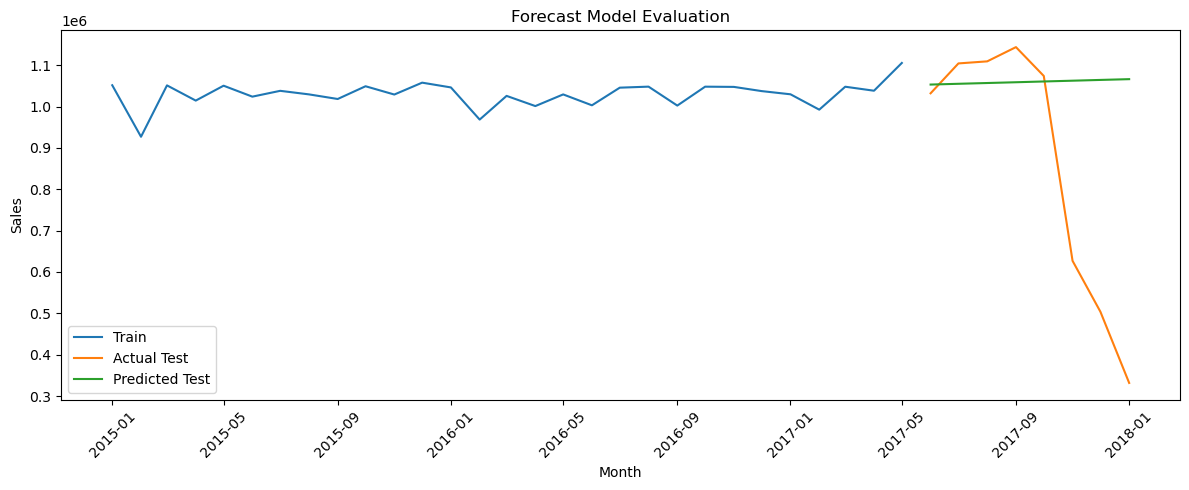

In [66]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Actual Test")
plt.plot(test.index, ets_predictions.values, label="Predicted Test")
plt.title("Forecast Model Evaluation")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
# =========================================================
# MODULE 15: BUSINESS INTERPRETATION
# =========================================================

latest_sales = monthly_data["monthly_sales"].iloc[-1]
future_avg_sales = forecast_summary["ets_sales_forecast"].mean()

latest_profit = monthly_data["monthly_profit"].iloc[-1]
future_avg_profit = forecast_summary["profit_forecast"].mean()

latest_quantity = monthly_data["monthly_quantity"].iloc[-1]
future_avg_quantity = forecast_summary["demand_forecast_quantity"].mean()

print("Business Forecast Interpretation")
print("="*60)

print(f"Latest Monthly Sales: {latest_sales:.2f}")
print(f"Average Forecasted Monthly Sales: {future_avg_sales:.2f}")

if future_avg_sales > latest_sales:
    print("Sales are expected to increase in the forecast period.")
else:
    print("Sales are expected to decline or remain below the latest month.")

print("-"*60)

print(f"Latest Monthly Profit: {latest_profit:.2f}")
print(f"Average Forecasted Monthly Profit: {future_avg_profit:.2f}")

if future_avg_profit > latest_profit:
    print("Profit is expected to improve.")
else:
    print("Profit may require attention in the coming months.")

print("-"*60)

print(f"Latest Monthly Demand Quantity: {latest_quantity:.2f}")
print(f"Average Forecasted Monthly Demand: {future_avg_quantity:.2f}")

if future_avg_quantity > latest_quantity:
    print("Inventory demand is expected to increase.")
else:
    print("Inventory demand is expected to remain stable or decrease.")

Business Forecast Interpretation
Latest Monthly Sales: 331650.12
Average Forecasted Monthly Sales: -269670.98
Sales are expected to decline or remain below the latest month.
------------------------------------------------------------
Latest Monthly Profit: 33841.89
Average Forecasted Monthly Profit: -12030.40
Profit may require attention in the coming months.
------------------------------------------------------------
Latest Monthly Demand Quantity: 2123.00
Average Forecasted Monthly Demand: 566.14
Inventory demand is expected to remain stable or decrease.


In [70]:
# =========================================================
# MODULE 16: SAVE FORECAST OUTPUTS
# =========================================================

forecast_summary_rounded.to_csv("forecast_summary.csv", index=False)
monthly_data.to_csv("monthly_forecasting_dataset.csv", index=False)

print("Forecasting outputs saved successfully.")

Forecasting outputs saved successfully.
